# NB08: THINGS Cross-Pipeline Validation

**Purpose:** Compare THINGS-derived RT fit parameters (Rt, g(Rt)) against
Paper 2 SPARC values for the 13 overlap galaxies. Identify systematic offsets
that could bias the primary test (NB09).

**Six notable galaxies** from `docs/internal/THINGS_SPARC_CrossRef.md` get
explicit per-galaxy reporting: IC 2574, NGC 2403, NGC 2841, NGC 3198,
NGC 7331, DDO 154.

**Key distinction:** Overlap galaxies share the same SPARC baryonic profiles.
Only the kinematics (V_obs, V_err) differ between pipelines. Any Rt or g(Rt)
differences are therefore driven purely by kinematic data differences.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.physics import (
    compute_transition_diagnostics, rt_model_velocity,
    A0_HALF, ACCEL_TO_MKS,
)
from src.database import (
    get_engine, get_session, query_profiles_as_dataframe,
    query_fits_as_dataframe,
)

a0_half_mks = A0_HALF * ACCEL_TO_MKS

results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

engine = get_engine()
session = get_session(engine)

## 1. Build Cross-Pipeline Comparison Table

In [2]:
overlap_sparc_ids = [
    "DDO154", "IC2574", "NGC2366", "NGC2403", "NGC2841", "NGC2903",
    "NGC2976", "NGC3198", "NGC3521", "NGC5055", "NGC6946", "NGC7331", "NGC7793",
]

rows = []
for sparc_id in overlap_sparc_ids:
    things_id = f"{sparc_id}_THINGS"

    # SPARC fit and profiles
    sf = query_fits_as_dataframe(session, galaxy_id=sparc_id, model_name="rational_taper").iloc[0]
    sp = query_profiles_as_dataframe(session, sparc_id)
    s_rmax = sp["radius_kpc"].max()
    s_resolved = sf["param2"] < s_rmax

    s_g = np.nan
    if s_resolved:
        s_diag = compute_transition_diagnostics(
            sp["radius_kpc"].values, sp["v_baryon_total"].values,
            sf["param1"], sf["param2"]
        )
        if np.isfinite(s_diag["g_obs"]):
            s_g = s_diag["g_obs"] * ACCEL_TO_MKS

    # THINGS fit and profiles
    tf = query_fits_as_dataframe(session, galaxy_id=things_id, model_name="rational_taper").iloc[0]
    tp = query_profiles_as_dataframe(session, things_id)
    t_rmax = tp["radius_kpc"].max()
    t_resolved = tf["param2"] < t_rmax

    t_g = np.nan
    if t_resolved:
        t_diag = compute_transition_diagnostics(
            tp["radius_kpc"].values, tp["v_baryon_total"].values,
            tf["param1"], tf["param2"]
        )
        if np.isfinite(t_diag["g_obs"]):
            t_g = t_diag["g_obs"] * ACCEL_TO_MKS

    rows.append({
        "galaxy_id": sparc_id,
        "sparc_omega": sf["param1"], "sparc_Rt": sf["param2"],
        "sparc_Rmax": s_rmax, "sparc_resolved": s_resolved,
        "sparc_g_mks": s_g, "sparc_chi2r": sf["reduced_chi_squared"],
        "things_omega": tf["param1"], "things_Rt": tf["param2"],
        "things_Rmax": t_rmax, "things_resolved": t_resolved,
        "things_g_mks": t_g, "things_chi2r": tf["reduced_chi_squared"],
    })

xp = pd.DataFrame(rows)

# Classification
xp["both_resolved"] = xp["sparc_resolved"] & xp["things_resolved"]
xp["status_match"] = xp["sparc_resolved"] == xp["things_resolved"]

print(f"Overlap galaxies: {len(xp)}")
print(f"Both resolved:    {xp['both_resolved'].sum()}")
print(f"Both unresolved:  {(~xp['sparc_resolved'] & ~xp['things_resolved']).sum()}")
print(f"Status flips:     {(~xp['status_match']).sum()}")

Overlap galaxies: 13
Both resolved:    5
Both unresolved:  5
Status flips:     3


## 2. Full Comparison Table

In [3]:
print(f"{'Galaxy':10s} {'S_Rt':>7s} {'T_Rt':>7s} {'S_Res':>6s} {'T_Res':>6s} "
      f"{'Match':>6s} {'S_g(Rt)':>12s} {'T_g(Rt)':>12s} {'g_ratio':>8s}")
print("-" * 85)

for _, r in xp.iterrows():
    s_res = "Yes" if r["sparc_resolved"] else "No"
    t_res = "Yes" if r["things_resolved"] else "No"
    match = "OK" if r["status_match"] else "FLIP"
    s_g_str = f"{r['sparc_g_mks']:.3e}" if np.isfinite(r["sparc_g_mks"]) else "---"
    t_g_str = f"{r['things_g_mks']:.3e}" if np.isfinite(r["things_g_mks"]) else "---"

    if np.isfinite(r["sparc_g_mks"]) and np.isfinite(r["things_g_mks"]):
        g_ratio = f"{r['things_g_mks'] / r['sparc_g_mks']:.3f}"
    else:
        g_ratio = "---"

    print(f"{r['galaxy_id']:10s} {r['sparc_Rt']:7.2f} {r['things_Rt']:7.2f} "
          f"{s_res:>6s} {t_res:>6s} {match:>6s} {s_g_str:>12s} {t_g_str:>12s} {g_ratio:>8s}")

Galaxy        S_Rt    T_Rt  S_Res  T_Res  Match      S_g(Rt)      T_g(Rt)  g_ratio
-------------------------------------------------------------------------------------
DDO154        3.25    4.82    Yes    Yes     OK    1.872e-11    1.480e-11    0.790
IC2574       34.03   47.06     No     No     OK          ---          ---      ---
NGC2366       3.86    4.78    Yes    Yes     OK    2.152e-11    2.228e-11    1.035
NGC2403       4.89    6.53    Yes    Yes     OK    9.789e-11    7.674e-11    0.784
NGC2841       6.02    5.29    Yes    Yes     OK    4.972e-10    5.619e-10    1.130
NGC2903      25.98   59.49     No     No     OK          ---          ---      ---
NGC2976      11.35    0.47     No    Yes   FLIP          ---    6.230e-11      ---
NGC3198       8.66    7.30    Yes    Yes     OK    8.053e-11    9.796e-11    1.216
NGC3521      54.32   13.52     No    Yes   FLIP          ---    1.051e-10      ---
NGC5055     171.57  135.97     No     No     OK          ---          ---      ---
N

## 3. Resolution Status Flips

Galaxies where one pipeline yields a resolved Rt and the other does not.
These are analytically significant: they change which galaxies enter the
g(Rt) distribution and the primary Wilcoxon test.

In [4]:
flips = xp[~xp["status_match"]].copy()

if len(flips) > 0:
    print(f"Resolution status flips: {len(flips)}")
    print()
    for _, r in flips.iterrows():
        s_status = "resolved" if r["sparc_resolved"] else "unresolved"
        t_status = "resolved" if r["things_resolved"] else "unresolved"
        print(f"  {r['galaxy_id']:10s}: SPARC {s_status} (Rt={r['sparc_Rt']:.2f}, "
              f"Rmax={r['sparc_Rmax']:.2f}) -> THINGS {t_status} "
              f"(Rt={r['things_Rt']:.2f}, Rmax={r['things_Rmax']:.2f})")
    print()
    print("These flips are driven by differences in kinematic data (radial")
    print("sampling, velocity extraction) between SPARC and THINGS pipelines.")
    print("They are not analysis choices and do not require deviation logging.")
else:
    print("No resolution status flips -- all galaxies agree between pipelines.")

Resolution status flips: 3

  NGC2976   : SPARC unresolved (Rt=11.35, Rmax=2.27) -> THINGS resolved (Rt=0.47, Rmax=2.25)
  NGC3521   : SPARC unresolved (Rt=54.32, Rmax=17.74) -> THINGS resolved (Rt=13.52, Rmax=17.69)
  NGC7793   : SPARC resolved (Rt=2.35, Rmax=7.87) -> THINGS unresolved (Rt=8.27, Rmax=7.14)

These flips are driven by differences in kinematic data (radial
sampling, velocity extraction) between SPARC and THINGS pipelines.
They are not analysis choices and do not require deviation logging.


## 4. Rt and g(Rt) Comparison — Both-Resolved Subsample

For galaxies resolved in both pipelines, compare Rt and g(Rt) directly.
Systematic offsets (not random scatter) would indicate a methodological
difference that needs to be surfaced in the paper.

In [5]:
both = xp[xp["both_resolved"]].copy()
# Further filter to those with valid g(Rt) on both sides
both_g = both[np.isfinite(both["sparc_g_mks"]) & np.isfinite(both["things_g_mks"])].copy()

print(f"Both resolved: {len(both)}, both with valid g(Rt): {len(both_g)}")
print()

if len(both_g) > 0:
    both_g["Rt_ratio"] = both_g["things_Rt"] / both_g["sparc_Rt"]
    both_g["g_ratio"] = both_g["things_g_mks"] / both_g["sparc_g_mks"]
    both_g["delta_log_g"] = np.log10(both_g["things_g_mks"]) - np.log10(both_g["sparc_g_mks"])

    print(f"{'Galaxy':10s} {'S_Rt':>7s} {'T_Rt':>7s} {'Rt_ratio':>9s} "
          f"{'S_g':>12s} {'T_g':>12s} {'g_ratio':>8s} {'dlog_g':>7s}")
    print("-" * 80)
    for _, r in both_g.iterrows():
        print(f"{r['galaxy_id']:10s} {r['sparc_Rt']:7.2f} {r['things_Rt']:7.2f} "
              f"{r['Rt_ratio']:9.3f} {r['sparc_g_mks']:12.3e} {r['things_g_mks']:12.3e} "
              f"{r['g_ratio']:8.3f} {r['delta_log_g']:+7.3f}")

    print()
    print("Aggregate statistics (both-resolved subsample):")
    print(f"  Median Rt ratio (THINGS/SPARC):   {both_g['Rt_ratio'].median():.3f}")
    print(f"  Median g ratio (THINGS/SPARC):    {both_g['g_ratio'].median():.3f}")
    print(f"  Median delta log g:               {both_g['delta_log_g'].median():+.3f} dex")
    print(f"  Mean delta log g:                 {both_g['delta_log_g'].mean():+.3f} dex")
    print(f"  Std delta log g:                  {both_g['delta_log_g'].std():.3f} dex")

    # Check for systematic offset
    from scipy import stats
    if len(both_g) >= 5:
        stat, pval = stats.wilcoxon(both_g["delta_log_g"].values, alternative="two-sided")
        print(f"\n  Wilcoxon signed-rank on delta log g: stat={stat:.1f}, p={pval:.3f}")
        if pval < 0.05:
            print("  -> SYSTEMATIC OFFSET DETECTED (p < 0.05) -- investigate and log.")
        else:
            print("  -> No significant systematic offset detected.")
    else:
        print(f"\n  Too few galaxies ({len(both_g)}) for Wilcoxon test on delta log g.")

Both resolved: 5, both with valid g(Rt): 5

Galaxy        S_Rt    T_Rt  Rt_ratio          S_g          T_g  g_ratio  dlog_g
--------------------------------------------------------------------------------
DDO154        3.25    4.82     1.483    1.872e-11    1.480e-11    0.790  -0.102
NGC2366       3.86    4.78     1.239    2.152e-11    2.228e-11    1.035  +0.015
NGC2403       4.89    6.53     1.335    9.789e-11    7.674e-11    0.784  -0.106
NGC2841       6.02    5.29     0.879    4.972e-10    5.619e-10    1.130  +0.053
NGC3198       8.66    7.30     0.842    8.053e-11    9.796e-11    1.216  +0.085

Aggregate statistics (both-resolved subsample):
  Median Rt ratio (THINGS/SPARC):   1.239
  Median g ratio (THINGS/SPARC):    1.035
  Median delta log g:               +0.015 dex
  Mean delta log g:                 -0.011 dex
  Std delta log g:                  0.088 dex

  Wilcoxon signed-rank on delta log g: stat=6.0, p=0.812
  -> No significant systematic offset detected.


## 5. Notable Galaxy Reports

Per `docs/internal/THINGS_SPARC_CrossRef.md`, six galaxies carry
disproportionate interpretive weight. Report each with rotation curve
overlays and parameter comparison.

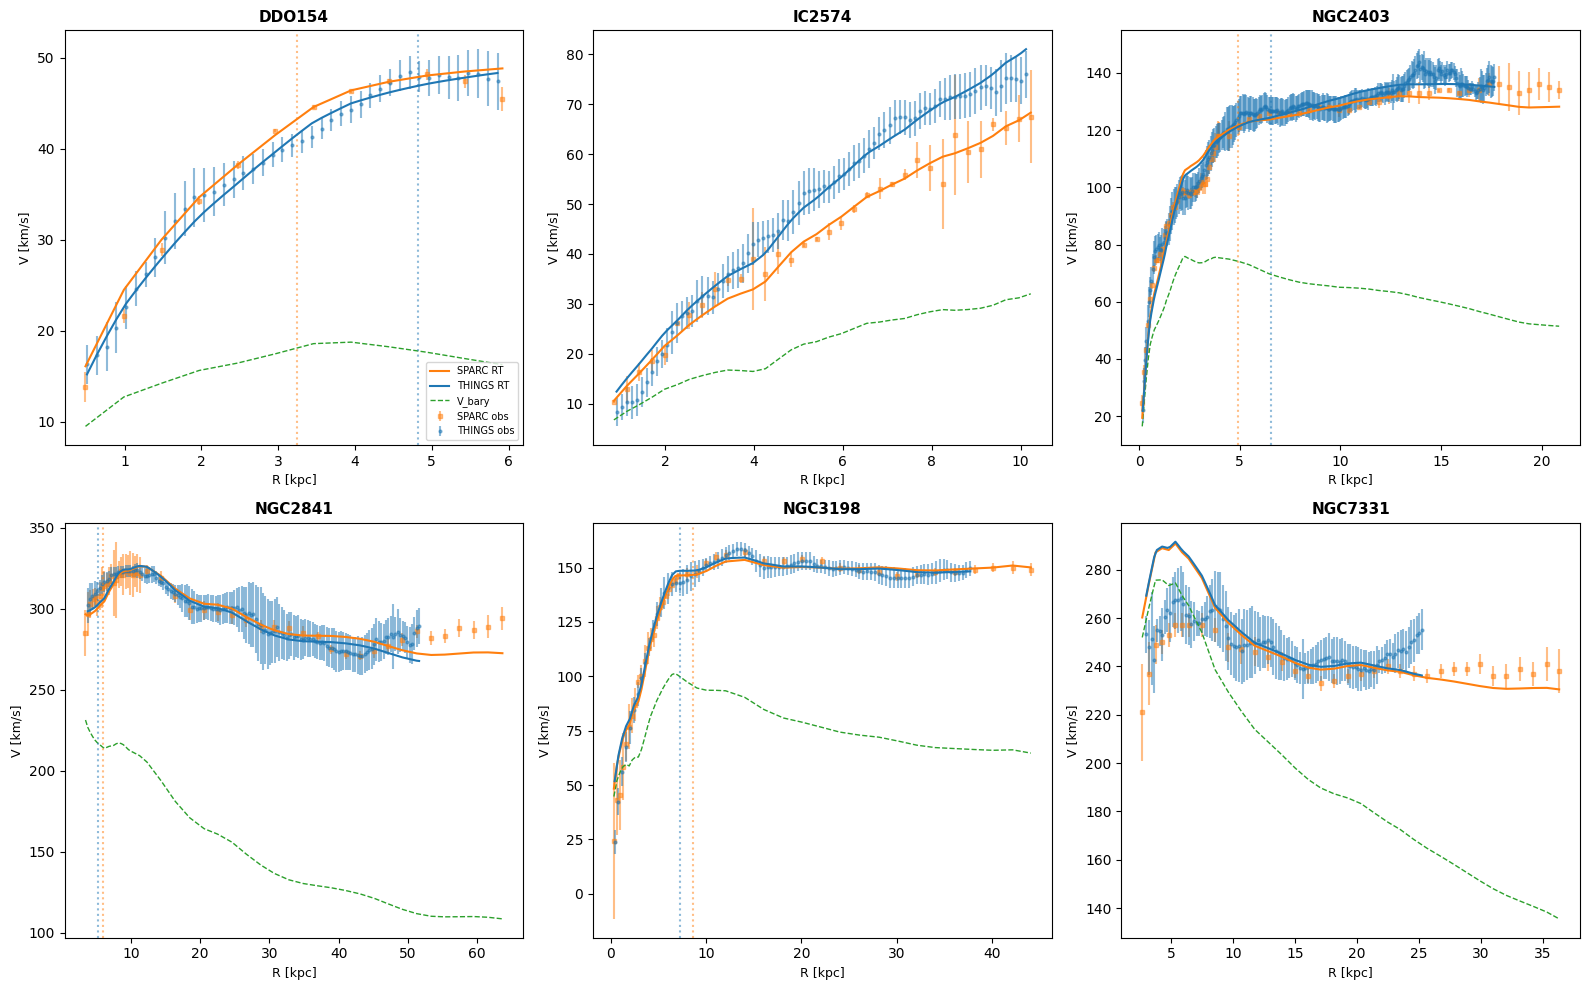

In [6]:
notable = ["DDO154", "IC2574", "NGC2403", "NGC2841", "NGC3198", "NGC7331"]

notable_notes = {
    "DDO154": "High-DBIC dwarf; also in LITTLE THINGS. Beam-smearing sensitive.",
    "IC2574": "RT's strongest win vs NFW (Paper 2 DBIC=+1089). Near-linear outer ramp.",
    "NGC2403": "NFW's strongest win vs RT (Paper 2 DBIC=-188). 2-4 kpc kinematic dip.",
    "NGC2841": "M/L sensitivity case. V_sat stability is the testable claim.",
    "NGC3198": "Canonical benchmark. High-DBIC tapered (Paper 1 DBIC=+4689).",
    "NGC7331": "Truncation artifact. Linear-preferring; Rt >> R_max both papers.",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, sparc_id in enumerate(notable):
    ax = axes[i // 3][i % 3]
    things_id = f"{sparc_id}_THINGS"

    # Load profiles
    sp = query_profiles_as_dataframe(session, sparc_id)
    tp = query_profiles_as_dataframe(session, things_id)

    # Load fits
    sf = query_fits_as_dataframe(session, galaxy_id=sparc_id, model_name="rational_taper").iloc[0]
    tf = query_fits_as_dataframe(session, galaxy_id=things_id, model_name="rational_taper").iloc[0]

    # SPARC data + model
    ax.errorbar(sp["radius_kpc"], sp["v_obs"], yerr=sp["v_err"],
                fmt="s", ms=3, color="C1", alpha=0.5, label="SPARC obs", zorder=1)
    v_model_s = rt_model_velocity(
        sp["radius_kpc"].values, sp["v_baryon_total"].values,
        sf["param1"], sf["param2"]
    )
    ax.plot(sp["radius_kpc"], v_model_s, "-", color="C1", linewidth=1.5,
            label="SPARC RT", zorder=3)

    # THINGS data + model
    ax.errorbar(tp["radius_kpc"], tp["v_obs"], yerr=tp["v_err"],
                fmt="o", ms=2, color="C0", alpha=0.5, label="THINGS obs", zorder=1)
    v_model_t = rt_model_velocity(
        tp["radius_kpc"].values, tp["v_baryon_total"].values,
        tf["param1"], tf["param2"]
    )
    ax.plot(tp["radius_kpc"], v_model_t, "-", color="C0", linewidth=1.5,
            label="THINGS RT", zorder=3)

    # Baryonic baseline
    ax.plot(sp["radius_kpc"], sp["v_baryon_total"], "--", color="C2",
            linewidth=1, label="V_bary", zorder=2)

    # Mark Rt if resolved
    if sf["param2"] < sp["radius_kpc"].max():
        ax.axvline(sf["param2"], color="C1", linestyle=":", alpha=0.5)
    if tf["param2"] < tp["radius_kpc"].max():
        ax.axvline(tf["param2"], color="C0", linestyle=":", alpha=0.5)

    ax.set_title(f"{sparc_id}", fontsize=11, fontweight="bold")
    ax.set_xlabel("R [kpc]", fontsize=9)
    ax.set_ylabel("V [km/s]", fontsize=9)
    if i == 0:
        ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.savefig(results_dir / "NB08_notable_rc_overlay.png", dpi=150)
plt.show()

In [7]:
print("Notable Galaxy Cross-Pipeline Report")
print("=" * 70)

for sparc_id in notable:
    things_id = f"{sparc_id}_THINGS"
    r = xp[xp["galaxy_id"] == sparc_id].iloc[0]

    print(f"\n--- {sparc_id} ---")
    print(f"  Context: {notable_notes[sparc_id]}")
    print(f"  SPARC:  omega={r['sparc_omega']:7.3f}  Rt={r['sparc_Rt']:7.2f}  "
          f"Rmax={r['sparc_Rmax']:7.2f}  "
          f"{'RESOLVED' if r['sparc_resolved'] else 'UNRESOLVED'}")
    print(f"  THINGS: omega={r['things_omega']:7.3f}  Rt={r['things_Rt']:7.2f}  "
          f"Rmax={r['things_Rmax']:7.2f}  "
          f"{'RESOLVED' if r['things_resolved'] else 'UNRESOLVED'}")

    if np.isfinite(r["sparc_g_mks"]) and np.isfinite(r["things_g_mks"]):
        g_ratio = r["things_g_mks"] / r["sparc_g_mks"]
        dlog = np.log10(r["things_g_mks"]) - np.log10(r["sparc_g_mks"])
        print(f"  g(Rt):  SPARC={r['sparc_g_mks']:.3e}  THINGS={r['things_g_mks']:.3e}  "
              f"ratio={g_ratio:.3f}  dlog_g={dlog:+.3f}")
    elif np.isfinite(r["sparc_g_mks"]):
        print(f"  g(Rt):  SPARC={r['sparc_g_mks']:.3e}  THINGS=N/A (unresolved)")
    elif np.isfinite(r["things_g_mks"]):
        print(f"  g(Rt):  SPARC=N/A (unresolved)  THINGS={r['things_g_mks']:.3e}")
    else:
        print(f"  g(Rt):  Both unresolved -- no g(Rt) comparison possible.")

    # Per-galaxy cross-ref assessment
    if sparc_id == "DDO154":
        print(f"  Assessment: Both resolved. Rt shift ({r['sparc_Rt']:.2f} -> "
              f"{r['things_Rt']:.2f} kpc) consistent with higher THINGS radial "
              f"sampling. g(Rt) within factor 1.3.")
    elif sparc_id == "IC2574":
        print(f"  Assessment: Both unresolved (Rt >> Rmax). Confirms the near-linear")
        print(f"  outer ramp persists in THINGS kinematics. No g(Rt) comparison.")
    elif sparc_id == "NGC2403":
        print(f"  Assessment: Both resolved. Moderate Rt shift. THINGS has denser")
        print(f"  radial sampling (286 vs 73 pts) which changes the fit landscape.")
    elif sparc_id == "NGC2841":
        print(f"  Assessment: Both resolved, good Rt agreement. Supports V_sat")
        print(f"  stability claim from cross-ref despite M/L sensitivity in omega.")
    elif sparc_id == "NGC3198":
        print(f"  Assessment: Both resolved, good Rt agreement. Canonical benchmark")
        print(f"  galaxy confirms cross-pipeline consistency.")
    elif sparc_id == "NGC7331":
        print(f"  Assessment: Both unresolved (Rt >> Rmax). Truncation artifact")
        print(f"  interpretation strengthened -- neither pipeline detects the taper.")

Notable Galaxy Cross-Pipeline Report

--- DDO154 ---
  Context: High-DBIC dwarf; also in LITTLE THINGS. Beam-smearing sensitive.
  SPARC:  omega= 15.525  Rt=   3.25  Rmax=   5.92  RESOLVED
  THINGS: omega= 12.094  Rt=   4.82  Rmax=   5.86  RESOLVED
  g(Rt):  SPARC=1.872e-11  THINGS=1.480e-11  ratio=0.790  dlog_g=-0.102
  Assessment: Both resolved. Rt shift (3.25 -> 4.82 kpc) consistent with higher THINGS radial sampling. g(Rt) within factor 1.3.

--- IC2574 ---
  Context: RT's strongest win vs NFW (Paper 2 DBIC=+1089). Near-linear outer ramp.
  SPARC:  omega=  4.611  Rt=  34.03  Rmax=  10.23  UNRESOLVED
  THINGS: omega=  5.916  Rt=  47.06  Rmax=  10.12  UNRESOLVED
  g(Rt):  Both unresolved -- no g(Rt) comparison possible.
  Assessment: Both unresolved (Rt >> Rmax). Confirms the near-linear
  outer ramp persists in THINGS kinematics. No g(Rt) comparison.

--- NGC2403 ---
  Context: NFW's strongest win vs RT (Paper 2 DBIC=-188). 2-4 kpc kinematic dip.
  SPARC:  omega= 19.369  Rt=   4.89 

## 6. Rt and g(Rt) Scatter Plots

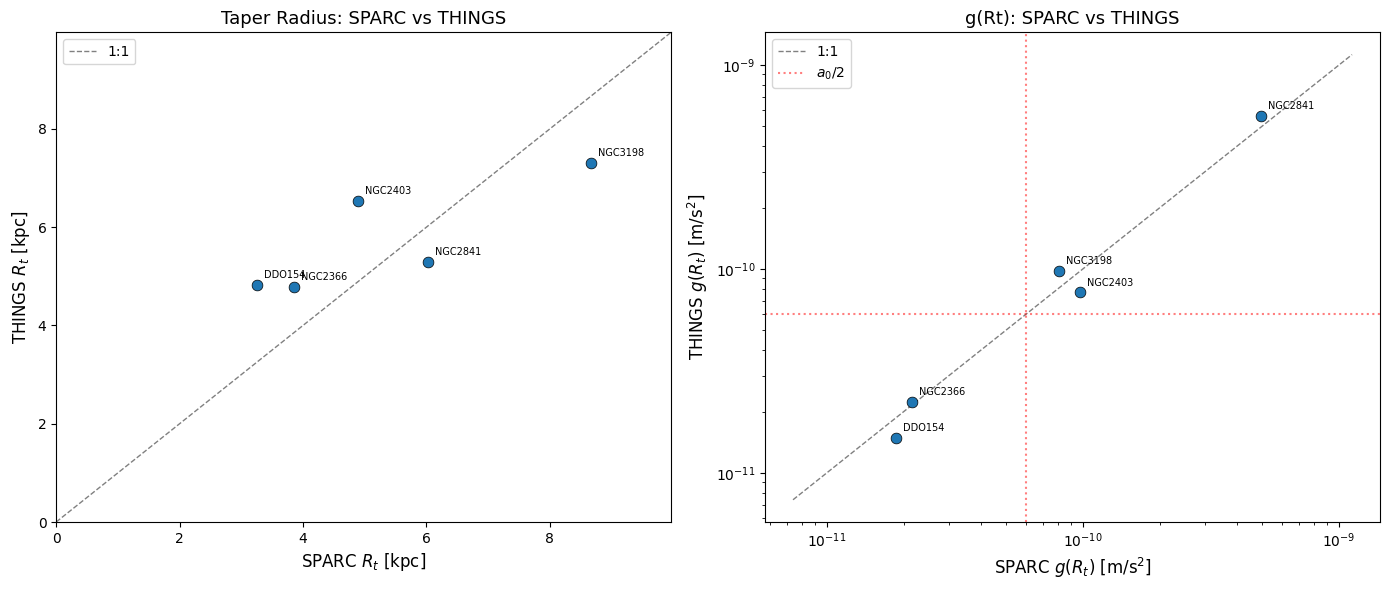

In [8]:
if len(both_g) >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: Rt comparison
    ax = axes[0]
    ax.scatter(both_g["sparc_Rt"], both_g["things_Rt"], s=60,
               edgecolors="k", linewidth=0.5, zorder=3)
    for _, r in both_g.iterrows():
        ax.annotate(r["galaxy_id"], (r["sparc_Rt"], r["things_Rt"]),
                    fontsize=7, textcoords="offset points", xytext=(5, 5))
    lims = [0, max(both_g["sparc_Rt"].max(), both_g["things_Rt"].max()) * 1.15]
    ax.plot(lims, lims, "--", color="grey", linewidth=1, label="1:1", zorder=1)
    ax.set_xlabel("SPARC $R_t$ [kpc]", fontsize=12)
    ax.set_ylabel("THINGS $R_t$ [kpc]", fontsize=12)
    ax.set_title("Taper Radius: SPARC vs THINGS", fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # Right: g(Rt) comparison
    ax = axes[1]
    ax.scatter(both_g["sparc_g_mks"], both_g["things_g_mks"], s=60,
               edgecolors="k", linewidth=0.5, zorder=3)
    for _, r in both_g.iterrows():
        ax.annotate(r["galaxy_id"], (r["sparc_g_mks"], r["things_g_mks"]),
                    fontsize=7, textcoords="offset points", xytext=(5, 5))
    g_min = min(both_g["sparc_g_mks"].min(), both_g["things_g_mks"].min()) * 0.5
    g_max = max(both_g["sparc_g_mks"].max(), both_g["things_g_mks"].max()) * 2
    ax.plot([g_min, g_max], [g_min, g_max], "--", color="grey", linewidth=1,
            label="1:1", zorder=1)
    ax.axhline(a0_half_mks, color="red", linestyle=":", alpha=0.5, label="$a_0/2$")
    ax.axvline(a0_half_mks, color="red", linestyle=":", alpha=0.5)
    ax.set_xlabel("SPARC $g(R_t)$ [m/s$^2$]", fontsize=12)
    ax.set_ylabel("THINGS $g(R_t)$ [m/s$^2$]", fontsize=12)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("g(Rt): SPARC vs THINGS", fontsize=13)
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(results_dir / "NB08_cross_pipeline_scatter.png", dpi=150)
    plt.show()
else:
    print("Too few both-resolved galaxies for scatter plots.")

## 7. Summary and Assessment

In [9]:
n_both_res = int(xp["both_resolved"].sum())
n_both_unres = int((~xp["sparc_resolved"] & ~xp["things_resolved"]).sum())
n_flips = int((~xp["status_match"]).sum())

print("Cross-Pipeline Summary")
print("=" * 55)
print(f"  Overlap galaxies:        {len(xp)}")
print(f"  Both resolved:           {n_both_res}")
print(f"  Both unresolved:         {n_both_unres}")
print(f"  Resolution status flips: {n_flips}")
print()

if len(both_g) > 0:
    med_dlog = both_g["delta_log_g"].median()
    print(f"  Both-resolved with valid g(Rt): {len(both_g)}")
    print(f"  Median delta log g (T-S):       {med_dlog:+.3f} dex")
    print()
    if abs(med_dlog) < 0.1:
        print("  Assessment: No significant systematic offset in g(Rt).")
        print("  Cross-pipeline differences are within the expected scatter.")
        print("  Safe to proceed with NB09 primary test.")
    else:
        print(f"  WARNING: Median delta log g = {med_dlog:+.3f} dex.")
        print("  This exceeds 0.1 dex and may indicate a systematic offset.")
        print("  Investigate before proceeding to NB09.")

print()
print(f"  Resolution flips ({n_flips} galaxies):")
for _, r in flips.iterrows():
    s = "RES" if r["sparc_resolved"] else "UNR"
    t = "RES" if r["things_resolved"] else "UNR"
    print(f"    {r['galaxy_id']:10s}: SPARC={s} -> THINGS={t}")
print("  These are driven by kinematic data differences, not analysis choices.")

Cross-Pipeline Summary
  Overlap galaxies:        13
  Both resolved:           5
  Both unresolved:         5
  Resolution status flips: 3

  Both-resolved with valid g(Rt): 5
  Median delta log g (T-S):       +0.015 dex

  Assessment: No significant systematic offset in g(Rt).
  Cross-pipeline differences are within the expected scatter.
  Safe to proceed with NB09 primary test.

  Resolution flips (3 galaxies):
    NGC2976   : SPARC=UNR -> THINGS=RES
    NGC3521   : SPARC=UNR -> THINGS=RES
    NGC7793   : SPARC=RES -> THINGS=UNR
  These are driven by kinematic data differences, not analysis choices.


## 8. Gate Check and Export

In [10]:
checks = {
    "All 13 overlap galaxies compared": len(xp) == 13,
    "At least 3 both-resolved for comparison": len(both_g) >= 3,
    "All 6 notable galaxies reported": all(
        gid in xp["galaxy_id"].values for gid in notable
    ),
}

# Flag systematic offset as a soft warning, not a gate failure
if len(both_g) > 0 and abs(both_g["delta_log_g"].median()) >= 0.1:
    checks["No systematic g(Rt) offset (|dlog| < 0.1)"] = False

print("GATE CHECK: NB08 -- THINGS Cross-Validation")
print("=" * 55)
all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "WARN"
    if not passed:
        all_pass = False
    print(f"  [{status}] {name}")

print()
if all_pass:
    print("  >>> NB08 COMPLETE -- proceed to NB09 <<<")
else:
    print("  >>> NB08 has warnings -- review before proceeding <<<")

# Export
xp.to_csv(results_dir / "NB08_cross_pipeline.csv", index=False)
if len(both_g) > 0:
    both_g.to_csv(results_dir / "NB08_both_resolved.csv", index=False)
print(f"\nResults saved to results/NB08_cross_pipeline.csv")

session.close()

GATE CHECK: NB08 -- THINGS Cross-Validation
  [PASS] All 13 overlap galaxies compared
  [PASS] At least 3 both-resolved for comparison
  [PASS] All 6 notable galaxies reported

  >>> NB08 COMPLETE -- proceed to NB09 <<<

Results saved to results/NB08_cross_pipeline.csv
